In [182]:
import numpy as np
import pandas as pd
loan=pd.read_csv("loan_model.csv")

Loading the new csv with new engineered feature.

In [183]:
loan.info()
loan.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 554 entries, 0 to 553
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             554 non-null    int64  
 1   Gender                 554 non-null    object 
 2   Married                554 non-null    object 
 3   Dependents             554 non-null    object 
 4   Education              554 non-null    object 
 5   Self_Employed          554 non-null    object 
 6   ApplicantIncome        554 non-null    int64  
 7   CoapplicantIncome      554 non-null    float64
 8   LoanAmount             554 non-null    float64
 9   Loan_Amount_Term       554 non-null    float64
 10  Credit_History         554 non-null    float64
 11  Property_Area          554 non-null    object 
 12  Loan_Status            554 non-null    object 
 13  Interest_Rate          554 non-null    int64  
 14  ApplicantIncome_log    554 non-null    float64
 15  Coappl

,Unnamed: 0,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,...,Interest_Rate,ApplicantIncome_log,CoapplicantIncome_log,LoanAmount_log,LoanAmount_IQR,Income_bin,Total_Income,Debt_to_Income,LTV_Proxy,Income_Band
0,0,Male,No,0,Graduate,No,5849,0.0,127.0,360.0,...,8,8.674197,0.000000,4.852030,127.0,High,5849.0,0.021713,1.058333,Medium
1,1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,...,8,8.430327,7.319202,4.859812,128.0,Upper-Middle,6091.0,0.021015,1.600000,Medium
2,2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,...,8,8.006701,0.000000,4.204693,66.0,Lower-Middle,3000.0,0.022000,0.550000,Low
3,3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,...,8,7.857094,7.765993,4.795791,120.0,Low,4941.0,0.024287,1.000000,Low
4,4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,...,8,8.699681,0.000000,4.955827,141.0,High,6000.0,0.023500,1.175000,Medium


In [184]:
loan = loan.drop(columns=['Unnamed: 0'])

## Encoding

In [185]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_vars = loan.select_dtypes(include=['object']).columns

for col in categorical_vars:
    loan[col] = label_encoder.fit_transform(loan[col])

In [186]:
#Encoding
obj = (loan.dtypes == 'object')
print("Categorical variables:",len(list(obj[obj].index)))

Categorical variables: 0


In [187]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 554 entries, 0 to 553
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Gender                 554 non-null    int64  
 1   Married                554 non-null    int64  
 2   Dependents             554 non-null    int64  
 3   Education              554 non-null    int64  
 4   Self_Employed          554 non-null    int64  
 5   ApplicantIncome        554 non-null    int64  
 6   CoapplicantIncome      554 non-null    float64
 7   LoanAmount             554 non-null    float64
 8   Loan_Amount_Term       554 non-null    float64
 9   Credit_History         554 non-null    float64
 10  Property_Area          554 non-null    int64  
 11  Loan_Status            554 non-null    int64  
 12  Interest_Rate          554 non-null    int64  
 13  ApplicantIncome_log    554 non-null    float64
 14  CoapplicantIncome_log  554 non-null    float64
 15  LoanAm

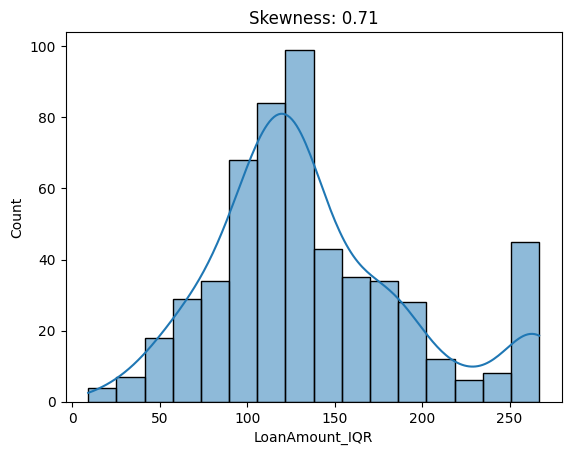

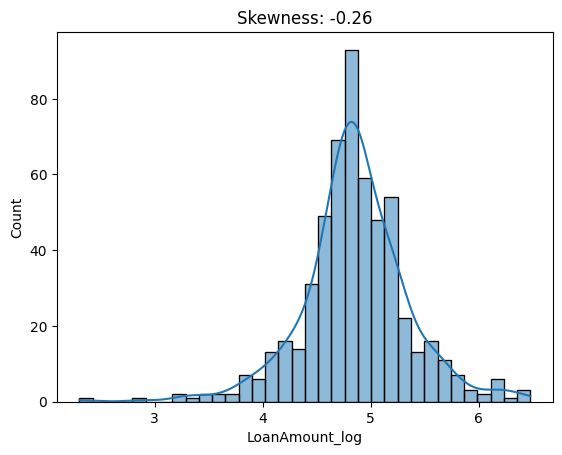

IQR Skewness: 0.7079076186682972
Log Skewness: -0.2561424033591042


In [188]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Visual Check
sns.histplot(loan['LoanAmount_IQR'], kde=True)
plt.title(f"Skewness: {loan['LoanAmount_IQR'].skew():.2f}")
plt.show()


sns.histplot(loan['LoanAmount_log'], kde=True)
plt.title(f"Skewness: {loan['LoanAmount_log'].skew():.2f}")
plt.show()

# 2. Statistical Check
print(f"IQR Skewness: {loan['LoanAmount_IQR'].skew()}")
print(f"Log Skewness: {loan['LoanAmount_log'].skew()}")

As the skewness of log_transform is in suitable range than IQR method so we keep LoanAmount_log for further analysis.

## **Correlation**

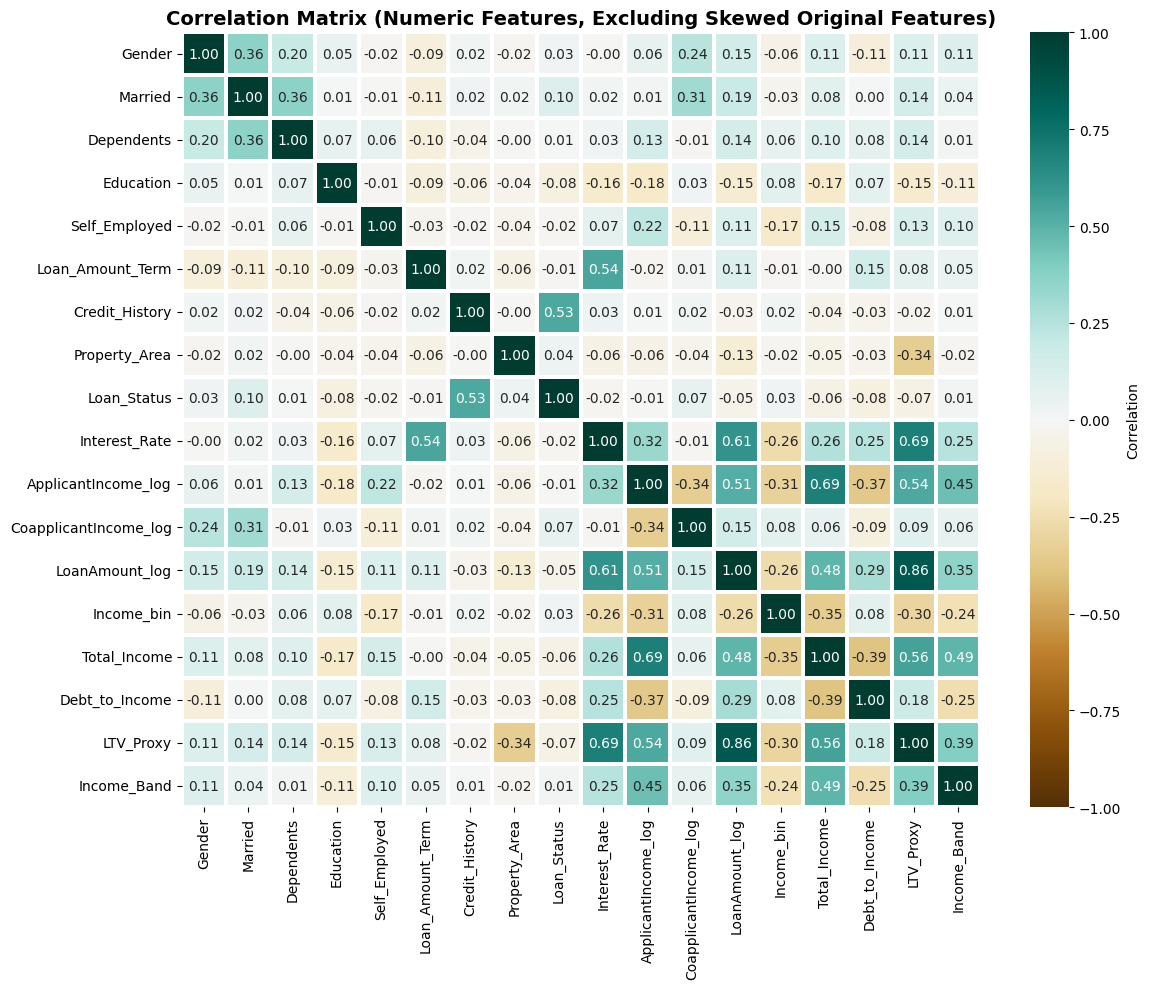

In [189]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude skewed original columns
exclude_cols = ['ApplicantIncome', 'CoapplicantIncome','LoanAmount','LoanAmount_IQR']

# Select numeric columns except the excluded ones
numeric_cols = [col for col in loan.select_dtypes(include=['number']).columns if col not in exclude_cols]
loan_numeric = loan[numeric_cols]

# Compute correlation matrix
corr_matrix = loan_numeric.corr()

# Plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='BrBG', annot=True, fmt='.2f', linewidths=1.5,
            vmin=-1, vmax=1, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix (Numeric Features, Excluding Skewed Original Features)', 
          fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

The LoanAmount_log is highly correlated with LTV_Proxy with 0.86 , and with ApplicantIncome_log with correlation value of 0.51,with Interest_Rate with correlation of value 0.61.

In [190]:
# Select numeric features for PCA (excluding target and skewed columns)
exclude_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Status']  # add target col if present
numeric_cols = [col for col in loan.select_dtypes(include=['number']).columns if col not in exclude_cols]
X = loan[numeric_cols]
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=0.95)  # keep 95% variance
X_pca = pca.fit_transform(X_scaled)

print("Number of components to retain 95% variance:", pca.n_components_)

Number of components to retain 95% variance: 13


In [191]:
X_pca.shape


(554, 13)